<a href="https://colab.research.google.com/github/tarynglover/tarynglover_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

#load data from colab notebook

data = pd.read_csv('car_purchase_data.csv')
display(data.head())
print('Shape:', data.shape)

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


Shape: (400, 5)


### Step 2: Split features and target

In [2]:
#features: dropping user ID b/c it's not revelant to car purchases
X = data[['Gender','Age', 'Salary']].copy() #using .copy() so I can encode gender column

#target:
y = data['Purchased']

#ran into an error in scaling due to gender being a string variable
#fix: encode the gender (categorical->numerical) using pd.map()

X['Gender'] = X['Gender'].map({'Male': 0, 'Female': 1})
#now male = 0, female = 1

print('X shape:', X.shape)
print('y distribution:\n', y.value_counts())
#check encoding
display(X.head())

X shape: (400, 3)
y distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


,Gender,Age,Salary
0,0,19,19000
1,0,35,20000
2,1,26,43000
3,1,27,57000
4,0,19,76000


### Step 3: Train/Test Split

In [3]:
#using a 80/20 split (first try)
#tried a 85/15 split to increase accuracy
#tried random state=10 to shuffle the split (increased accuracy!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=10, stratify=y
)
print('Train size:', X_train.shape[0], ' Test size:', X_test.shape[0])

Train size: 340  Test size: 60


### Step 4: Feature Scaling

In [4]:
#using sklearn standardscaler

scaler = StandardScaler()
X_train[['Age','Salary']] = scaler.fit_transform(X_train[['Age','Salary']])
X_test[['Age','Salary']]  = scaler.transform(X_test[['Age','Salary']])
print('Scaling complete.')

#realized maybe I shouldn't have scaled the gender column at all b/c it's binary!
#leaving the binary encoding unless it affects the accuracy

Scaling complete.


### Step 5: Train Logistic Regression Model

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print('Model trained.')

Model trained.


### Step 6: Predict and Evaluate

In [6]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print('Accuracy:', acc)
print('\nConfusion Matrix:\n', cm)
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.9166666666666666

Confusion Matrix:
 [[37  2]
 [ 3 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94        39
           1       0.90      0.86      0.88        21

    accuracy                           0.92        60
   macro avg       0.91      0.90      0.91        60
weighted avg       0.92      0.92      0.92        60



In [7]:
print(model.coef_)

[[-0.22788945  2.15122732  1.11625049]]


### Step 7: Visualization of Decision Regions

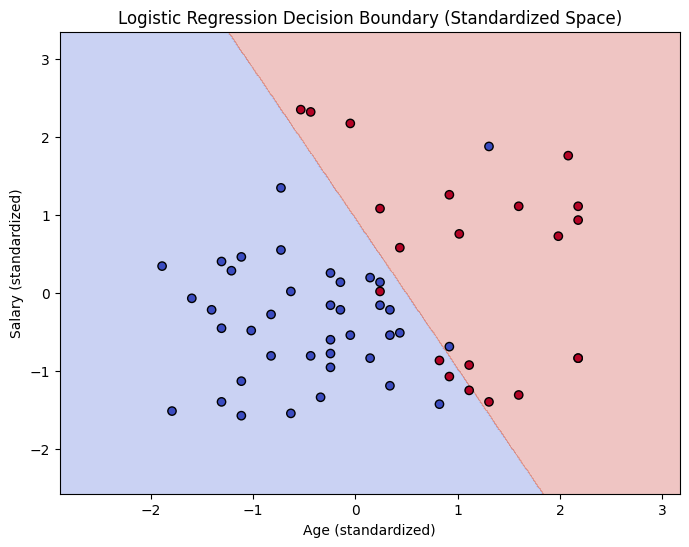

In [9]:
#I want to use age v. salary in the visual
import numpy as np
import matplotlib.pyplot as plt

X_train_2d = X_train[['Age', 'Salary']]
X_test_2d  = X_test[['Age', 'Salary']]

X_set = X_test_2d.values
y_set = y_test.values

#train 2D model
model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(X_train_2d.values, y_train)

x1_min, x1_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
x2_min, x2_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
X1, X2 = np.meshgrid(
    np.arange(start=x1_min, stop=x1_max, step=0.01),
    np.arange(start=x2_min, stop=x2_max, step=0.01)
)

Z = model_2d.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

plt.figure(figsize=(8,6))
plt.contourf(X1, X2, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, edgecolor='k', cmap='coolwarm')
plt.title('Logistic Regression Decision Boundary (Standardized Space)')
plt.xlabel('Age (standardized)')
plt.ylabel('Salary (standardized)')
plt.show()


## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. Because the logistic regression is predicting a probability between 0 and 1, it can still be classified as either 0 or 1 using some kind of threshold to categorize each probability. For example, the threshold between 0 and 1 would most likely be .5, so values greater than or equal to .5 would be classified as 1 (purchased) and less than .5 would be 0 (not purchased). These probabilities can become a classification using a simple decision rule.

2. Based on the visualization of decisions, the model shows that people of higher age and higher salaries are the most likely to purchase a car. I think the model's interpretations follow the logic that consumers with more financial freedom and at a later stage in life are more likely to buy a car.

3. I struggled somewhat with my orginal code falling around a 84% accuracy and did some troubleshooting to raise the accuracy. I checked the coeffcients of the 3 X values and found that gender had a very minimal impact on decisions, so I tried to remove that from the X features, but that resulted in a lower accuracy.
Then, I focused on adjusting the scalability and removed gender from the feature scaling all together since it is a binary feature. That had no affect on the accuracy, so I kept the feature scaling as is.
Finally I adjusted the train/test split from 80/20 to 85/15 because the sample size of the dataset was relatively small. This raised the accuracy to about 86%, so I adjusted the random state to 10 so there would be some variability. This resulted in the model evaluating with an accuracy of about 91.7%!
 Other factors that may cause lower accuracy would be overlaps in the data, meaning customers that fall very close to the boundary being difficult for the model to separate. Additionally, there were only 2 features in this dataset with strong impact on the decision, so the lack of features could impact the model. Lastly, the logistic regression model only allows for a straight line boundary, but the real world decision making may be more complex than that.

4. I think additional features would be the most impactful as there are more factors in the real world that impact car purchasing.
Some I might suggest are: credit score, amount of debt, and location. In the preprocessing stage, there might be some feature engineering that could combine and capture impact better. For example debt-income ratio might be more meaningful than either feature individually.
Additionally, removing outliers might prevent skewing in the model.